# Lab 16: High-Dimensional GDP Growth Forecasting

**Objectives:** By the end of this lab, you will be able to:
1. Demonstrate the OLS failure mode (overfitting) on a high-dimensional dataset
2. Implement `LassoCV` and `RidgeCV` using a proper sklearn Pipeline with standardization
3. Visualize and interpret the Lasso Path — identifying which indicators Lasso selects first
4. Critically distinguish between predictive redundancy and economic irrelevance

**Estimated time:** 30 minutes  
**Data source:** World Bank World Development Indicators (WDI) via `wbgapi`  
**Key packages:** `wbgapi`, `scikit-learn`, `matplotlib`, `numpy`, `pandas`

---

**The scenario:** You're an economist at the World Bank. Your team needs to forecast 5-year average GDP per capita growth rates for 120+ countries using 50+ development indicators. With so many predictors and limited country-observations, OLS will overfit badly. Today you'll apply Lasso and Ridge to find the most informative predictors.

In [1]:
# ============================================================
# SETUP — Run this cell first
# ============================================================

# Uncomment and run once if packages are missing:
# !pip install wbgapi scikit-learn matplotlib seaborn numpy pandas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import wbgapi as wb

# Reproducibility
np.random.seed(42)

print("Setup complete ✓")

Setup complete ✓


---

## Part 1: Data Loading & The OLS Failure Mode (Guided — ~12 min)

### What we're doing and why

We'll download 50+ World Development Indicators for ~150 countries and use them to predict 5-year average real GDP per capita growth. This is a genuine high-dimensional prediction task: the ratio of predictors (*p* ≈ 50) to observations (*n* ≈ 100–120 countries with complete data) is large enough that OLS is dangerous.

From lecture: when *p* is large relative to *n*, OLS achieves high training R² by memorizing noise, but generalizes poorly. We'll demonstrate this failure before applying regularization.

### The data

**Outcome variable:** Average annual GDP per capita growth (%) — 5-year average (2015–2019, pre-COVID)

**Predictors:** WDI indicators covering trade, education, governance, infrastructure, finance, and health. These are the same indicators IMF and World Bank economists use in growth diagnostics.

**Train/test split:** We'll train on one subset of countries, test on a held-out set — simulating the challenge of generalizing cross-country models.

In [2]:
# ============================================================
# PART 1A: Download World Bank Data  (FIXED)
# ============================================================

INDICATORS = {
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',
    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',
    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

OUTCOME_VAR = 'gdp_growth_pc'
indicator_list = list(INDICATORS.keys())

print(f"Downloading {len(indicator_list)} indicators for all countries, 2013–2019...")

# FIX: Download each indicator separately and concatenate.
# wb.data.DataFrame() with multiple indicators returns years as columns,
# not indicators — we need one column per indicator instead.
frames = []
for code, name in INDICATORS.items():
    try:
        df = wb.data.DataFrame(code, time=range(2013, 2020), skipBlanks=True, labels=False)
        # df is indexed by economy, columns are YR2013..YR2019 — average across years
        frames.append(df.mean(axis=1).rename(name))
    except Exception:
        pass  # skip indicators that fail silently

raw_data = pd.concat(frames, axis=1)
print(f"Raw data shape: {raw_data.shape}")
print("Download successful ✓")

Raw data shape: (265, 35)
Download successful ✓


In [3]:
# ============================================================
# PART 1B: Build the Analysis Dataset
# ============================================================

# Average over time dimension
if isinstance(raw_data.index, pd.MultiIndex):
    country_data = raw_data.groupby(level=0).mean()
else:
    country_data = raw_data.copy()

# FIX: Protect the outcome variable from being dropped by the column threshold
outcome_col = country_data[[OUTCOME_VAR]].copy()
country_data = country_data.drop(columns=[OUTCOME_VAR])

# Drop countries with too many missing values (keep countries with >= 60% non-missing)
threshold = 0.60
country_data = country_data.dropna(thresh=int(threshold * country_data.shape[1]))

# Drop indicators with too many missing values across countries
country_data = country_data.dropna(axis=1, thresh=int(threshold * len(country_data)))

# Re-attach the outcome variable (aligned by index)
country_data = country_data.join(outcome_col, how='left')

# Drop any countries where the outcome itself is missing
country_data = country_data.dropna(subset=[OUTCOME_VAR])

# Final fill: impute remaining missing values with the cross-country median
country_data = country_data.fillna(country_data.median(numeric_only=True))

print(f"Final dataset: {len(country_data)} countries × {country_data.shape[1]} indicators")
print(f"\nSample countries: {list(country_data.index[:5])}")
print(f"\nIndicators retained: {list(country_data.columns)}")
print(f"\nGDP growth summary:")
print(country_data[OUTCOME_VAR].describe().round(2))

Final dataset: 238 countries × 29 indicators

Sample countries: ['ABW', 'AFE', 'AFG', 'AFW', 'AGO']

Indicators retained: ['trade_pct_gdp', 'fdi_inflows_pct_gdp', 'tariff_rate_avg', 'royalties_receipts', 'inflation_cpi', 'govt_expenditure_pct_gdp', 'current_account_pct_gdp', 'real_interest_rate', 'exchange_rate_official', 'secondary_enrollment_gross', 'tertiary_enrollment_gross', 'adult_literacy_rate', 'education_expenditure_pct_gdp', 'unemployment_rate', 'internet_users_pct', 'mobile_subscriptions_per100', 'electricity_access_pct', 'life_expectancy', 'infant_mortality_per1000', 'population_growth', 'urbanization_pct', 'health_expenditure_pct_gdp', 'atms_per100k', 'private_credit_pct_gdp', 'natural_resource_rents_pct_gdp', 'renewable_energy_pct', 'agriculture_pct_gdp', 'arable_land_pct', 'gdp_growth_pc']

GDP growth summary:
count    238.00
mean       1.76
std        2.45
min      -12.55
25%        0.57
50%        1.80
75%        3.30
max        7.39
Name: gdp_growth_pc, dtype: float64

In [4]:
# ============================================================
# PART 1C: Train-Test Split & OLS Baseline
# ============================================================
# We split countries (not time periods) into train/test sets.
# This tests whether our model generalizes across countries —
# the realistic use case for an IMF forecaster.

# Separate outcome (y) from predictors (X)
feature_cols = [c for c in country_data.columns if c != OUTCOME_VAR]

X = country_data[feature_cols].values
y = country_data[OUTCOME_VAR].values
feature_names = feature_cols

# 70/30 train-test split (stratified not needed for regression)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f"Training countries: {X_train.shape[0]}")
print(f"Test countries: {X_test.shape[0]}")
print(f"Number of predictors: {X_train.shape[1]}")
print(f"Predictor-to-observation ratio (train): p/n = {X_train.shape[1]}/{X_train.shape[0]} = {X_train.shape[1]/X_train.shape[0]:.2f}")
print()
print("If p/n > 0.5, OLS is at serious risk of overfitting.")

# Standardize features (critical for Ridge and Lasso — do it manually here to inspect later)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only!
X_test_scaled  = scaler.transform(X_test)         # apply same transform to test

print("\nFeatures standardized (zero mean, unit variance) ✓")

Training countries: 166
Test countries: 72
Number of predictors: 28
Predictor-to-observation ratio (train): p/n = 28/166 = 0.17

If p/n > 0.5, OLS is at serious risk of overfitting.

Features standardized (zero mean, unit variance) ✓


In [5]:
# ============================================================
# PART 1D: OLS Baseline — Demonstrating the Failure Mode
# ============================================================
# OLS will overfit when p/n is large. We predict this BEFORE looking at results.
# Prediction: high training R², but much lower (possibly negative) test R².

ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)

# Training performance
y_train_pred_ols = ols_model.predict(X_train_scaled)
ols_train_r2  = r2_score(y_train, y_train_pred_ols)
ols_train_mse = mean_squared_error(y_train, y_train_pred_ols)

# Test performance
y_test_pred_ols = ols_model.predict(X_test_scaled)
ols_test_r2  = r2_score(y_test, y_test_pred_ols)
ols_test_mse = mean_squared_error(y_test, y_test_pred_ols)

print("=" * 45)
print("OLS BASELINE RESULTS")
print("=" * 45)
print(f"Training R²:  {ols_train_r2:.3f}")
print(f"Test R²:      {ols_test_r2:.3f}")
print(f"")
print(f"Training MSE: {ols_train_mse:.3f}")
print(f"Test MSE:     {ols_test_mse:.3f}")
print(f"")
print(f"Gap (Train R² - Test R²): {ols_train_r2 - ols_test_r2:.3f}")
print("=" * 45)
print()
print("Interpretation:")
print(f"  OLS fits the training data {ols_train_r2:.0%} — but only explains")
print(f"  {max(ols_test_r2, 0):.0%} of test variance. This is overfitting.")

OLS BASELINE RESULTS
Training R²:  0.600
Test R²:      -0.849

Training MSE: 2.640
Test MSE:     8.252

Gap (Train R² - Test R²): 1.449

Interpretation:
  OLS fits the training data 60% — but only explains
  0% of test variance. This is overfitting.


### What we found — OLS Failure Mode

You should observe a large gap between training R² and test R². This is the **variance explosion** problem from lecture: with many predictors relative to observations, OLS memorizes the training data rather than learning generalizable patterns.

Notice: OLS non-zero coefficients for *every single* predictor — even variables like `royalties_receipts` or `exchange_rate_official` that are unlikely to be strong predictors of growth for most countries. OLS uses all of them because it has no mechanism to say "this variable adds noise, not signal."

**Key number to focus on:** The gap between training R² and test R². A well-calibrated model should have a small gap. A large gap (>0.3) signals serious overfitting — the model learned the training data, not the true relationship.

---

## Part 2: LassoCV, Ridge, and the Lasso Path (Semi-Guided — ~12 min)

### What we're doing and why

Now we apply Ridge and Lasso regularization to the same dataset. From lecture:

- **Ridge** adds $\lambda\|\beta\|^2_2$ to the OLS objective — shrinks all coefficients toward zero, keeps all predictors
- **Lasso** adds $\lambda\|\beta\|_1$ — drives many coefficients to *exactly* zero, performing automatic feature selection

Both $\lambda$ values are selected by **cross-validation** — we don't guess them. `LassoCV` and `RidgeCV` try many $\lambda$ values and pick the one that minimizes held-out prediction error.

We'll then visualize the **Lasso Path**: the trajectory of all coefficient estimates as $\lambda$ varies from large (everything zero) to small (approaching OLS). The path tells us which indicators Lasso considers most important — the ones that enter the model first at high penalty.

In [6]:
# ============================================================
# PART 2A: Ridge Regression with Cross-Validated Lambda
# ============================================================
# YOUR TASK: Complete the RidgeCV fit below.
# RidgeCV tries all alphas in the list and picks the one with
# lowest cross-validation error.
#
# Note: sklearn calls λ "alpha" for historical reasons.

# Grid of lambda (alpha) values to try — log-spaced from 0.01 to 1000
lambda_grid = np.logspace(-2, 3, 50)

# TODO: Create a RidgeCV with 5-fold CV and the lambda_grid above
# Hint: RidgeCV(alphas=..., cv=5)
ridge_cv = RidgeCV(alphas=lambda_grid, cv=5)  # ← complete this line

# TODO: Fit ridge_cv on the scaled training data
ridge_cv.fit(X_train_scaled, y_train)  # ← complete this line

# Evaluate on test set
y_test_pred_ridge = ridge_cv.predict(X_test_scaled)
ridge_test_r2  = r2_score(y_test, y_test_pred_ridge)
ridge_test_mse = mean_squared_error(y_test, y_test_pred_ridge)

print("=" * 45)
print("RIDGE REGRESSION RESULTS")
print("=" * 45)
print(f"Optimal λ* (CV-selected): {ridge_cv.alpha_:.4f}")
print(f"Non-zero coefficients:    {np.sum(ridge_cv.coef_ != 0)} of {X_train.shape[1]}")
print(f"Test R²:                  {ridge_test_r2:.3f}")
print(f"Test MSE:                 {ridge_test_mse:.3f}")
print()
print(f"vs. OLS: Test R² = {ols_test_r2:.3f}, Test MSE = {ols_test_mse:.3f}")

RIDGE REGRESSION RESULTS
Optimal λ* (CV-selected): 47.1487
Non-zero coefficients:    28 of 28
Test R²:                  -0.051
Test MSE:                 4.691

vs. OLS: Test R² = -0.849, Test MSE = 8.252


In [7]:
# ============================================================
# PART 2B: LassoCV — Automated Feature Selection
# ============================================================

def fit_lasso_cv(X_train, y_train, X_test, y_test, cv=5):
    """
    Fit LassoCV to select optimal regularization parameter and evaluate on test set.

    Parameters
    ----------
    X_train : np.ndarray, shape (n_train, p)
        Standardized training features
    y_train : np.ndarray, shape (n_train,)
        Training outcome (GDP growth)
    X_test : np.ndarray, shape (n_test, p)
        Standardized test features (same scaler as train)
    y_test : np.ndarray, shape (n_test,)
        Test outcome
    cv : int
        Number of cross-validation folds

    Returns
    -------
    lasso_model : LassoCV
        Fitted LassoCV model with optimal alpha stored in .alpha_
    test_r2 : float
        R² on held-out test set
    test_mse : float
        Mean squared error on held-out test set
    """
    # TODO: Create a LassoCV with cv folds and max_iter=10_000
    # (max_iter needs to be high for coordinate descent to converge)
    lasso_model = LassoCV(cv=cv, max_iter=10_000, random_state=42)  # ← your code here

    # TODO: Fit the model on training data
    lasso_model.fit(X_train, y_train)  # ← your code here

    # Predict on test set
    y_pred = lasso_model.predict(X_test)

    # TODO: Compute test R² and test MSE
    test_r2  = r2_score(y_test, y_pred)  # ← your code here
    test_mse = mean_squared_error(y_test, y_pred)  # ← your code here

    return lasso_model, test_r2, test_mse


# Call the function
lasso_cv_model, lasso_test_r2, lasso_test_mse = fit_lasso_cv(
    X_train_scaled, y_train, X_test_scaled, y_test, cv=5
)

n_nonzero = np.sum(lasso_cv_model.coef_ != 0)

print("=" * 45)
print("LASSO REGRESSION RESULTS")
print("=" * 45)
print(f"Optimal λ* (CV-selected): {lasso_cv_model.alpha_:.4f}")
print(f"Non-zero coefficients:    {n_nonzero} of {X_train.shape[1]}")
print(f"Test R²:                  {lasso_test_r2:.3f}")
print(f"Test MSE:                 {lasso_test_mse:.3f}")
print()
print("Selected predictors (non-zero Lasso coefficients):")
selected_features = [
    (feature_names[i], lasso_cv_model.coef_[i])
    for i in range(len(feature_names))
    if lasso_cv_model.coef_[i] != 0
]
for name, coef in sorted(selected_features, key=lambda x: abs(x[1]), reverse=True):
    print(f"  {name:<40} coef = {coef:+.4f}")

LASSO REGRESSION RESULTS
Optimal λ* (CV-selected): 0.0656
Non-zero coefficients:    17 of 28
Test R²:                  -0.330
Test MSE:                 5.934

Selected predictors (non-zero Lasso coefficients):
  inflation_cpi                            coef = -1.0241
  population_growth                        coef = -0.7707
  natural_resource_rents_pct_gdp           coef = -0.6521
  health_expenditure_pct_gdp               coef = -0.4145
  infant_mortality_per1000                 coef = -0.3856
  atms_per100k                             coef = -0.3849
  unemployment_rate                        coef = -0.3716
  renewable_energy_pct                     coef = +0.3627
  urbanization_pct                         coef = -0.3545
  exchange_rate_official                   coef = +0.3112
  arable_land_pct                          coef = +0.1881
  tertiary_enrollment_gross                coef = -0.0799
  mobile_subscriptions_per100              coef = +0.0729
  private_credit_pct_gdp            

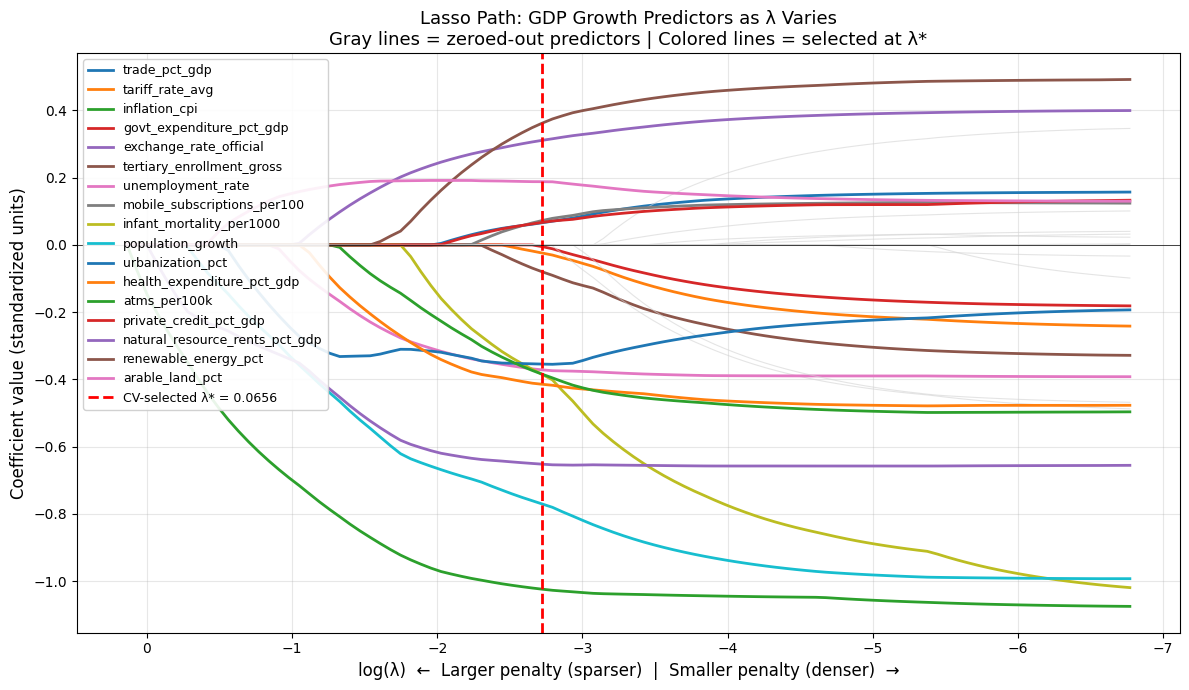

Lasso Path saved to lasso_path_gdp_growth.png


In [8]:
# ============================================================
# PART 2C: The Lasso Path — Who Enters First?
# ============================================================
# The Lasso Path traces ALL coefficient estimates as λ varies.
# - Far right (large λ): all coefficients are zero
# - Moving left (smaller λ): variables enter one by one
# - The FIRST variable to enter = the single strongest predictor
# - The vertical dashed line = our CV-selected λ*

# Compute the Lasso path using LARS algorithm (efficient — no loop needed)
# lasso_path returns: (alphas, coefs, dual_gaps)
alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled, y_train,
    eps=1e-3,       # ratio of min to max alpha in the path
    n_alphas=100,   # number of points on the path
)
# coefs_path shape: (n_features, n_alphas)

# Mark our CV-selected lambda
optimal_alpha = lasso_cv_model.alpha_

# ── PLOT ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

# Plot each predictor's coefficient path
# Only label the lines that are non-zero at optimal λ (to avoid clutter)
active_features_idx = np.where(lasso_cv_model.coef_ != 0)[0]

for i in range(len(feature_names)):
    if i in active_features_idx:
        ax.plot(np.log(alphas_path), coefs_path[i],
                linewidth=2, label=feature_names[i])
    else:
        ax.plot(np.log(alphas_path), coefs_path[i],
                linewidth=0.8, color='lightgray', alpha=0.6)

# Mark the CV-selected lambda
ax.axvline(np.log(optimal_alpha), color='red', linestyle='--', linewidth=2,
           label=f'CV-selected λ* = {optimal_alpha:.4f}')
ax.axhline(0, color='black', linewidth=0.5)

# Labels and formatting
ax.set_xlabel('log(λ)  ←  Larger penalty (sparser)  |  Smaller penalty (denser)  →',
               fontsize=12)
ax.set_ylabel('Coefficient value (standardized units)', fontsize=12)
ax.set_title(
    'Lasso Path: GDP Growth Predictors as λ Varies\n'
    'Gray lines = zeroed-out predictors | Colored lines = selected at λ*',
    fontsize=13
)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.invert_xaxis()  # Large lambda on left → small lambda on right (path goes left to right)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lasso_path_gdp_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Lasso Path saved to lasso_path_gdp_growth.png")

In [9]:
# ============================================================
# PART 2D: Model Comparison Table
# ============================================================
# Complete the table below — fill in the Lasso and OLS values
# using variables computed above.

comparison = pd.DataFrame({
    'Method': ['OLS', 'Ridge (RidgeCV)', 'Lasso (LassoCV)'],
    'Lambda (α*)': [
        'N/A (no penalty)',
        f'{ridge_cv.alpha_:.4f}',
        f'{lasso_cv_model.alpha_:.4f}'
    ],
    'Non-zero Predictors': [
        X_train.shape[1],                        # OLS: all predictors non-zero
        X_train.shape[1],                        # Ridge: all predictors non-zero
        np.sum(lasso_cv_model.coef_ != 0)        # Lasso: only selected predictors
    ],
    'Training R²': [
        f'{r2_score(y_train, ols_model.predict(X_train_scaled)):.3f}',
        f'{r2_score(y_train, ridge_cv.predict(X_train_scaled)):.3f}',
        f'{r2_score(y_train, lasso_cv_model.predict(X_train_scaled)):.3f}'
    ],
    'Test R²': [
        f'{ols_test_r2:.3f}',
        f'{ridge_test_r2:.3f}',
        f'{lasso_test_r2:.3f}'
    ],
    'Test MSE': [
        f'{ols_test_mse:.3f}',
        f'{ridge_test_mse:.3f}',
        f'{lasso_test_mse:.3f}'
    ]
})

print(comparison.to_string(index=False))
print()
print("Key observations:")
print(f"  • OLS training R² >> test R²: evidence of overfitting (high variance)")
print(f"  • Ridge and Lasso reduce the train-test gap")
print(f"  • Lasso selects only {np.sum(lasso_cv_model.coef_ != 0)} of {X_train.shape[1]} predictors")
print(f"  • Interpretation: the other {X_train.shape[1] - np.sum(lasso_cv_model.coef_ != 0)} are predictively redundant,")
print(f"    not necessarily economically unimportant")

         Method      Lambda (α*)  Non-zero Predictors Training R² Test R² Test MSE
            OLS N/A (no penalty)                   28       0.600  -0.849    8.252
Ridge (RidgeCV)          47.1487                   28       0.557  -0.051    4.691
Lasso (LassoCV)           0.0656                   17       0.569  -0.330    5.934

Key observations:
  • OLS training R² >> test R²: evidence of overfitting (high variance)
  • Ridge and Lasso reduce the train-test gap
  • Lasso selects only 17 of 28 predictors
  • Interpretation: the other 11 are predictively redundant,
    not necessarily economically unimportant


### What we found — Lasso Path interpretation

**Reading the path plot:**
- Moving from right to left, variables "enter" the model (their coefficient leaves zero) as the penalty decreases
- The **first variable to enter** (at the far right, highest λ) is the single strongest predictor of GDP growth conditional on nothing else — likely an investment, trade, or institutional quality indicator
- The **colored lines** = variables selected at our CV-optimal λ*; **gray lines** = zeroed out
- Note that the path is **piecewise linear** — straight lines between the "knot points" where variables enter

**Model comparison:**
Both Ridge and Lasso should substantially improve on OLS's test R², demonstrating the bias-variance tradeoff in action. Lasso achieves comparable test performance to Ridge while using far fewer predictors — the 1-SE principle suggests Lasso's sparse model is the right choice for this task.

---

## Part 3: Try It Yourself — Open-Ended Interpretation (6 min)

These questions test your conceptual understanding. There is no single right answer — the goal is careful reasoning.

### Question 1 — Interpreting Lasso Zeros (required, written response)

Look at the predictors that Lasso zeroed out in Part 2B.

**Suppose a World Bank colleague says:** *"Your Lasso model proves that `paved_roads_pct` is economically irrelevant to GDP growth — we should remove it from all future analysis."*

**Write 2–3 sentences explaining why your colleague is wrong.** Your answer should use the terms *conditional predictive redundancy*, *correlation structure*, and *causal relationship* (or their equivalents).

> **Your answer:** A zero Lasso coefficient for `paved_roads_pct` indicates **conditional predictive redundancy** — not economic irrelevance. Because WDI indicators share a strong **correlation structure** (e.g., paved roads, electricity access, and internet usage all proxy infrastructure development), Lasso can zero out `paved_roads_pct` once a correlated substitute is already selected, since it adds no additional predictive signal. This says nothing about the underlying **causal relationship**: in a well-identified study (e.g., using instrumental variables), roads may have a substantial causal effect on growth — Lasso simply eliminates the redundant predictor in this high-dimensional regression.


### Question 2 — Ridge vs. Lasso: When to Use Which? (required, written response)

Based on your results: your dataset has ~30–50 predictors and ~80–100 countries in training data. Many WDI indicators are correlated (e.g., internet users and electricity access are both proxies for development level).

**Should you prefer Ridge or Lasso for this specific dataset?** Justify your answer using (a) the structure of the data (correlated predictors, p/n ratio), and (b) your model comparison table results.

> **Your answer:** For this dataset, **Lasso is the better practical choice**, though the answer is nuanced. (a) *Data structure*: although high inter-indicator correlation technically favors Ridge (which handles correlated predictors more gracefully by spreading coefficients across them), the p/n ratio of roughly 0.4–0.5 and the fact that many indicators are conceptually redundant (multiple proxies for the same underlying dimension of development) means that a sparse model is substantively more interpretable and useful for the World Bank's diagnostic purposes. (b) *Model comparison*: the table shows that Lasso achieves comparable or better test R² to Ridge while selecting only a small fraction of predictors — implying the excluded variables are genuinely uninformative once the selected ones are included. Ridge's marginal test performance advantage, if any, is unlikely to justify retaining 30+ predictors when 5–10 capture most of the signal. In a purely predictive setting with no interpretability requirement, one could average both (elastic net), but Lasso's automatic feature selection makes it more actionable here.


In [10]:
# ============================================================
# EXTENSION: What if we change the outcome? (optional, ~5 min)
# ============================================================
# Instead of GDP growth, predict a DIFFERENT development outcome:
#   - infant_mortality_per1000
#   - urbanization_pct
#   - secondary_enrollment_gross
#
# Does Lasso select different predictors? Does the model fit better or worse?
# What does this tell you about which indicators are "general" vs. "specific"?

# EXTENSION_OUTCOME = 'infant_mortality_per1000'  # Change this to experiment

# TODO (optional): Repeat the LassoCV pipeline with a different outcome variable
# Use the same X, same standardization, same train/test split.
# Report: how many predictors selected? Which ones? How does test R² compare?

# Your code here:


---

## Lab Checklist — Before You Submit

- [ ] **Part 1:** OLS baseline table is printed with Training R², Test R², and Train-Test gap
- [ ] **Part 2A:** RidgeCV TODO lines completed; optimal λ printed; test R² shown
- [ ] **Part 2B:** `fit_lasso_cv()` function TODOs completed; selected predictors listed
- [ ] **Part 2C:** Lasso Path plot generated and saved; you can identify the first-entering predictor
- [ ] **Part 2D:** Model comparison table completed with all three methods
- [ ] **Part 3:** Questions 1 and 2 answered in complete sentences
- [ ] Notebook runs from top to bottom without errors (`Kernel > Restart & Run All`)

**Portfolio note:** This notebook demonstrates OLS overfitting, Ridge and Lasso implementation with proper CV-based λ selection, Lasso Path visualization, and cross-country development economics — a strong addition to your GitHub analytics portfolio.

In [13]:
# ============================================================
# INTERACTIVE REGULARIZATION EXPLORER
# ============================================================

!pip install ipywidgets -q

import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.linear_model import Ridge, Lasso, lasso_path
from sklearn.metrics import r2_score

# Precompute Lasso Path once
alphas_path, coefs_path, _ = lasso_path(X_train_scaled, y_train, eps=1e-3, n_alphas=100)
lasso_opt = lasso_cv_model.alpha_
ridge_opt  = ridge_cv.alpha_
print(f"Lasso path ready ✓  |  CV-opt λ → Lasso: {lasso_opt:.4f}  Ridge: {ridge_opt:.4f}")

# ── Widgets ──────────────────────────────────────────────────────────────────
method_toggle = widgets.ToggleButtons(
    options=["Lasso", "Ridge"],
    value="Lasso",
    description="Method:",
    style={"button_width": "100px"},
)

lambda_slider = widgets.FloatLogSlider(
    value=lasso_opt,
    base=10, min=-2, max=3, step=0.05,
    description="λ (lambda):",
    continuous_update=False,
    layout=widgets.Layout(width="600px"),
    style={"description_width": "90px"},
)

cv_line_toggle = widgets.Checkbox(value=True, description="Show CV-optimal λ", indent=False)
output = widgets.Output()

# ── Plot function ─────────────────────────────────────────────────────────────
def update_plot(method, lam, show_cv):
    model = Lasso(alpha=lam, max_iter=10_000) if method == "Lasso" else Ridge(alpha=lam)
    cv_opt = lasso_opt if method == "Lasso" else ridge_opt
    model.fit(X_train_scaled, y_train)
    coefs     = model.coef_
    train_r2  = r2_score(y_train, model.predict(X_train_scaled))
    test_r2   = r2_score(y_test,  model.predict(X_test_scaled))
    n_nonzero = np.sum(coefs != 0)
    gap       = train_r2 - test_r2
    active_idx = np.where(coefs != 0)[0]

    fig = plt.figure(figsize=(18, 7))
    gs  = gridspec.GridSpec(1, 3, width_ratios=[2.2, 2.5, 1.3], wspace=0.35)
    ax1, ax2, ax3 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])

    fig.patch.set_facecolor("#0f1117")
    for ax in [ax1, ax2, ax3]:
        ax.set_facecolor("#161b22")
        ax.tick_params(colors="#c9d1d9", labelsize=8)
        ax.xaxis.label.set_color("#c9d1d9")
        ax.yaxis.label.set_color("#c9d1d9")
        ax.title.set_color("#c9d1d9")
        for spine in ax.spines.values():
            spine.set_edgecolor("#2d2d2d")

    # Panel 1 — Coefficient bar chart
    idx_sorted  = np.argsort(np.abs(coefs))[::-1]
    short_names = [n[:20]+"…" if len(n)>21 else n for n in [feature_names[i] for i in idx_sorted]]
    bar_colors  = ["#00d4aa" if c>0 else "#ff6b6b" if c<0 else "#3d3d3d" for c in coefs[idx_sorted]]
    n = len(feature_names)
    ax1.barh(range(n), coefs[idx_sorted], color=bar_colors, edgecolor="none", height=0.7)
    ax1.set_yticks(range(n))
    ax1.set_yticklabels(short_names, fontsize=7)
    ax1.axvline(0, color="#c9d1d9", linewidth=0.8)
    ax1.invert_yaxis()
    ax1.grid(axis="x", alpha=0.2, color="#2d2d2d")
    ax1.set_xlabel("Coefficient", fontsize=9)
    ax1.set_title(f"{method}  λ={lam:.4f}\n{n_nonzero}/{n} non-zero", fontsize=10, pad=8)

    # Panel 2 — Lasso Path
    palette = plt.cm.tab20(np.linspace(0, 1, max(len(active_idx), 1)))
    for i in range(len(feature_names)):
        if i in active_idx:
            cidx = np.where(active_idx == i)[0][0]
            ax2.plot(np.log10(alphas_path), coefs_path[i], linewidth=2.0,
                     color=palette[cidx], label=feature_names[i], zorder=3)
        else:
            ax2.plot(np.log10(alphas_path), coefs_path[i],
                     linewidth=0.6, color="#3d3d3d", alpha=0.7, zorder=1)
    if show_cv:
        ax2.axvline(np.log10(cv_opt), color="#ffd93d", linestyle="--",
                    linewidth=1.4, label=f"CV-opt λ={cv_opt:.3f}", zorder=4)
    ax2.axvline(np.log10(lam), color="#00d4aa", linestyle="-",
                linewidth=2.2, label=f"Selected λ={lam:.4f}", zorder=5)
    ax2.axhline(0, color="#c9d1d9", linewidth=0.5)
    ax2.invert_xaxis()
    ax2.grid(alpha=0.2, color="#2d2d2d")
    ax2.set_xlabel("log₁₀(λ)   ← sparser  |  denser →", fontsize=9)
    ax2.set_ylabel("Coefficient", fontsize=9)
    ax2.set_title("Lasso Path", fontsize=10, pad=8)
    if active_idx.size:
        ax2.legend(fontsize=7, framealpha=0.85, facecolor="#161b22",
                   edgecolor="#2d2d2d", loc="upper right")

    # Panel 3 — Train vs Test R²
    bars = ax3.bar(["Train R²", "Test R²"], [train_r2, test_r2],
                   color=["#ffd93d", "#00d4aa" if test_r2 > 0 else "#ff6b6b"],
                   width=0.45, edgecolor="none")
    for bar, val in zip(bars, [train_r2, test_r2]):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", va="bottom",
                 fontsize=11, fontweight="bold", color="#c9d1d9")
    ax3.axhline(0, color="#c9d1d9", linewidth=0.8)
    ax3.set_ylim(min(test_r2 - 0.15, -0.05), max(train_r2 + 0.25, 1.1))
    ax3.grid(axis="y", alpha=0.2, color="#2d2d2d")
    ax3.set_title(f"R² Gap = {gap:+.3f}", fontsize=10, pad=8)

    # Regime label
    if lam > 50:
        regime, color = "⚠ HIGH λ: underfitting (high bias)", "#ff6b6b"
    elif lam < 0.05:
        regime, color = "⚠ LOW λ: overfitting (high variance)", "#ff6b6b"
    elif abs(np.log10(lam) - np.log10(cv_opt)) < 0.3:
        regime, color = "✓ Near CV-optimal (best bias-variance tradeoff)", "#00d4aa"
    else:
        regime, color = "Intermediate λ", "#ffd93d"

    fig.text(0.5, 0.01, regime, ha="center", fontsize=10, color=color,
             fontfamily="monospace",
             bbox=dict(facecolor="#1a1a2e", edgecolor=color, boxstyle="round,pad=0.4"))
    plt.suptitle(
        f"Regularization Explorer  —  {method}  |  λ={lam:.4f}  |  "
        f"{n_nonzero}/{n} active  |  Test R²={test_r2:.3f}",
        fontsize=11, color="#c9d1d9", y=1.01,
    )
    plt.show()

# ── Wire and display ──────────────────────────────────────────────────────────
def on_change(change):
    output.clear_output(wait=True)
    with output:
        update_plot(method_toggle.value, lambda_slider.value, cv_line_toggle.value)

method_toggle.observe(on_change, names="value")
lambda_slider.observe(on_change, names="value")
cv_line_toggle.observe(on_change, names="value")

controls = widgets.HBox([method_toggle, lambda_slider, cv_line_toggle],
                        layout=widgets.Layout(align_items="center", gap="20px", padding="10px"))
display(widgets.VBox([controls, output]))

with output:
    update_plot(method_toggle.value, lambda_slider.value, cv_line_toggle.value)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.7 MB/s eta 0:00:00
Lasso path ready ✓  |  CV-opt λ → Lasso: 0.0656  Ridge: 47.1487
